# Human-in-the-Loop with LangChain

Human-in-the-loop means that a person can review an agent action before it runs.

This notebook uses the current LangChain agent API and a checkpointer so the agent can pause and resume safely.

We will approve or reject a simulated email tool. The tool does not send a real email.

## How the workflow works

1. The user asks the agent to perform an action.
2. The agent chooses a tool.
3. Middleware pauses before the tool runs.
4. A person approves or rejects the action.
5. The same conversation resumes with the decision.

## 1. Imports and model

`create_agent` builds the agent. `HumanInTheLoopMiddleware` controls approval. `InMemorySaver` stores the paused state while learning.

For production, use a durable checkpointer instead of `InMemorySaver`.

In [15]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
import os 
from dotenv import load_dotenv
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("CHAT_MODEL")

llm = init_chat_model(model=MODEL)

In [16]:
llm.invoke('hi')

AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EC6ZV9Cf8FVI96RPfuaK8kBCuVbqu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff6e9-2a28-7410-8ee2-6ece02ed4ff6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 2. Define a tool

The `@tool` decorator exposes a Python function to the agent.

This example returns a confirmation message instead of performing a real external action.

In [2]:
@tool
def send_email(recipient: str, subject: str, body: str) -> str:
    """Simulate sending an email after human approval."""
    return f"Simulated email sent to {recipient}: {subject}"

## 3. Add approval middleware

`interrupt_on` maps tool names to approval behavior:

- `True`: pause and allow the default decisions.
- `False`: run without pausing.
- A dictionary: configure decisions such as `approve`, `reject`, or `edit`.

`description_prefix` explains why the human is being asked to review the action.

In [4]:
approval_middleware = HumanInTheLoopMiddleware(
    interrupt_on={
        "send_email": {
            "allowed_decisions": ["approve", "reject", "edit"]
        }
    },
    description_prefix="Approval required before sending an email"
)

## 4. Create the agent

The `checkpointer` is required because the agent must save its state while paused.

The `thread_id` used later identifies one resumable conversation. A different thread ID starts a separate conversation.

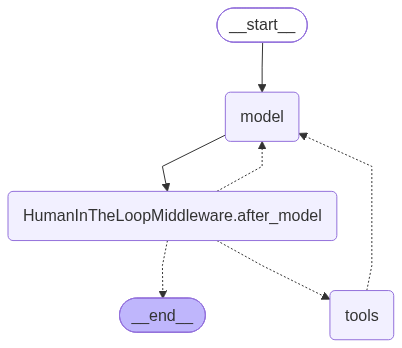

In [18]:
checkpointer = InMemorySaver()

agent = create_agent(
    model=llm,
    tools=[send_email],
    middleware=[approval_middleware],
    checkpointer=checkpointer
)

config = {
    "configurable": {
        "thread_id": "hitl-demo-1"
    }
}

agent

## 5. Start the request

The agent should stop before `send_email` executes. The returned `__interrupt__` value contains the action that needs review.

In [19]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Email sara@example.com that the report is ready."
            }
        ]
    },
    config=config
)

interrupts = result.get("__interrupt__", [])
interrupts

[]

## 6. Approve and resume

`Command(resume=...)` continues the same paused thread.

The decision must be sent as a list because a workflow can contain more than one pending approval.

In [20]:
final_result = agent.invoke(
    Command(
        resume={
            "decisions": [
                {"type": "approve"}
            ]
        }
    ),
    config=config
)

final_result["messages"][-1].content

'I can do that, but I need your approval to send the email.\n\n**To:** sara@example.com  \n**Subject:** Report Ready  \n**Body:** Hi Sara, the report is ready. Best regards,'

## 7. Reject an action

Use `reject` when the action should not run. The agent receives the rejection and can explain what happened.

In [21]:
rejected_result = agent.invoke(
    Command(
        resume={
            "decisions": [
                {"type": "reject", "message": "Do not send this email."}
            ]
        }
    ),
    config=config
)

In [26]:
def print_agent_response(result):
    """Print the latest assistant message from an agent result."""
    if "__interrupt__" in result:
        return

    messages = result.get("messages", [])

    if messages:
        print(f"Assistant: {messages[-1].content}")


In [31]:
def run_chatbot(agent, thread_id: str):
    """Run an interactive chatbot with human approval for protected tools."""
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    print("Chatbot started. Type 'quit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"quit", "exit"}:
            print("Chatbot stopped.")
            break

        if not user_input:
            continue
            
        result = agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": user_input
                    }
                ]
            },
            config=config
        )

        print(result)

        interrupts = result.get("__interrupt__", [])

        if not interrupts:
            print_agent_response(result)
            continue

        print("\nHuman approval required.")
        print(interrupts[0].value)

        # ############################################### TAKING USER INPUT 
        decision = input(
            "\nEnter 'approve' or 'reject': "
        ).strip().lower()

        while decision not in {"approve", "reject"}:
            decision = input(
                "Please enter only 'approve' or 'reject': "
            ).strip().lower()


        ####################################################### BUILD ING RESUME VALUE BASED ON USER DECISION
        if decision == "approve":
            resume_value = {
                "decisions": [
                    {
                        "type": "approve"
                    }
                ]
            }
        else:
            resume_value = {
                "decisions": [
                    {
                        "type": "reject",
                        "message": "The human reviewer rejected this action."
                    }
                ]
            }

        ################################################ USE COMMAND TO RESUME THE AGENT WITH THE USER DECISION
        resumed_result = agent.invoke(
            Command(resume=resume_value),
            config=config
        )

        print_agent_response(resumed_result)

In [32]:
run_chatbot(agent, thread_id="user-1")

Chatbot started. Type 'quit' to stop.
{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='990f5a48-6cb8-438f-a441-313266248196'), AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 136, 'total_tokens': 148, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EC6dk0iWT07t7bsSbf5a0xO2YgcwL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff6ed-3399-74b1-867a-f8948c4ff932-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 136, 'output_tokens': 12, 'total_tokens': 148, 'input_token_details':

## Important production notes

- Never execute sensitive tools before the approval decision.
- Use a durable checkpointer when a pause may last longer than the process lifetime.
- Treat approval as authorization for the exact tool call, not for an unrelated later action.
- Validate tool arguments again inside the tool or service boundary.
- Store the reviewer, decision, timestamp, and tool arguments for auditing.
- Use a unique `thread_id` for each independent conversation.